# **Joseph Benedict Sy**

# **2ECE-C**

In [53]:
import pandas as pd

In [54]:
import matplotlib.pyplot as plt

In [55]:
df = pd.read_excel('board2.xlsx')
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [56]:
df.describe()

,Math,Electronics,GEAS,Communication
count,30.000000,30.00000,30.000000,30.000000
mean,72.166667,61.60000,71.866667,61.966667
std,12.660237,17.29381,15.725519,15.376837
min,48.000000,35.00000,40.000000,41.000000
25%,64.250000,47.00000,61.250000,49.000000
50%,73.500000,60.00000,76.000000,60.000000
75%,83.000000,76.50000,83.750000,72.750000
max,89.000000,91.00000,94.000000,88.000000


### **A. Visayas Communication DataFrame**

In [57]:
# Calculate Average first on a temporary dataframe copy to keep the original df intact
temp_df = df.copy()
temp_df['Average'] = temp_df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

In [58]:
# Apply explicit conditions for Hometown and Track
VisComm = temp_df[(temp_df['Hometown'] == 'Visayas') & (temp_df['Track'] == 'Communication')]

In [59]:
# Select and reorder columns correctly
VisComm = VisComm[['Name', 'Gender', 'Math', 'Electronics', 'Average']]

In [60]:
# Display the DataFrame and its row count
print(f"Number of rows: {len(VisComm)}")
VisComm

Number of rows: 5


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


### **B. Visayas Female DataFrame**

In [61]:
# Calculate Average first on a temporary dataframe copy to keep the original df intact
temp_df = df.copy()
temp_df['Average'] = temp_df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

# Filter for students whose Hometown is Visayas and Gender is Female
VisFemale = temp_df[(temp_df['Hometown'] == 'Visayas') & (temp_df['Gender'] == 'Female')]

In [62]:
# Filter for students whose Hometown is Visayas and Gender is Female
VisFemale = temp_df[(temp_df['Hometown'] == 'Visayas') & (temp_df['Gender'] == 'Female')]

In [63]:
# Retain only: Name, Track, GEAS, Electronics, Average
VisFemale = VisFemale[['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

In [64]:
# Display the entire VisFemale DataFrame
print("Complete VisFemale DataFrame:")
VisFemale

Complete VisFemale DataFrame:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [65]:
# Filter and display students whose Average is at least 60 without overwriting VisFemale
print("\nStudents with Average >= 60:")
VisFemale[VisFemale['Average'] >= 60.0]


Students with Average >= 60:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


### **C. CATEGORY-AVERAGE VISUALIZATION**


Mean Average by Track:


,Average
Track,
Communication,67.975
Instrumentation,65.225
Microelectronics,67.500



Mean Average by Gender:


,Average
Gender,
Female,66.616667
Male,67.183333



Mean Average by Hometown:


,Average
Hometown,
Luzon,68.083333
Mindanao,66.678571
Visayas,65.750000


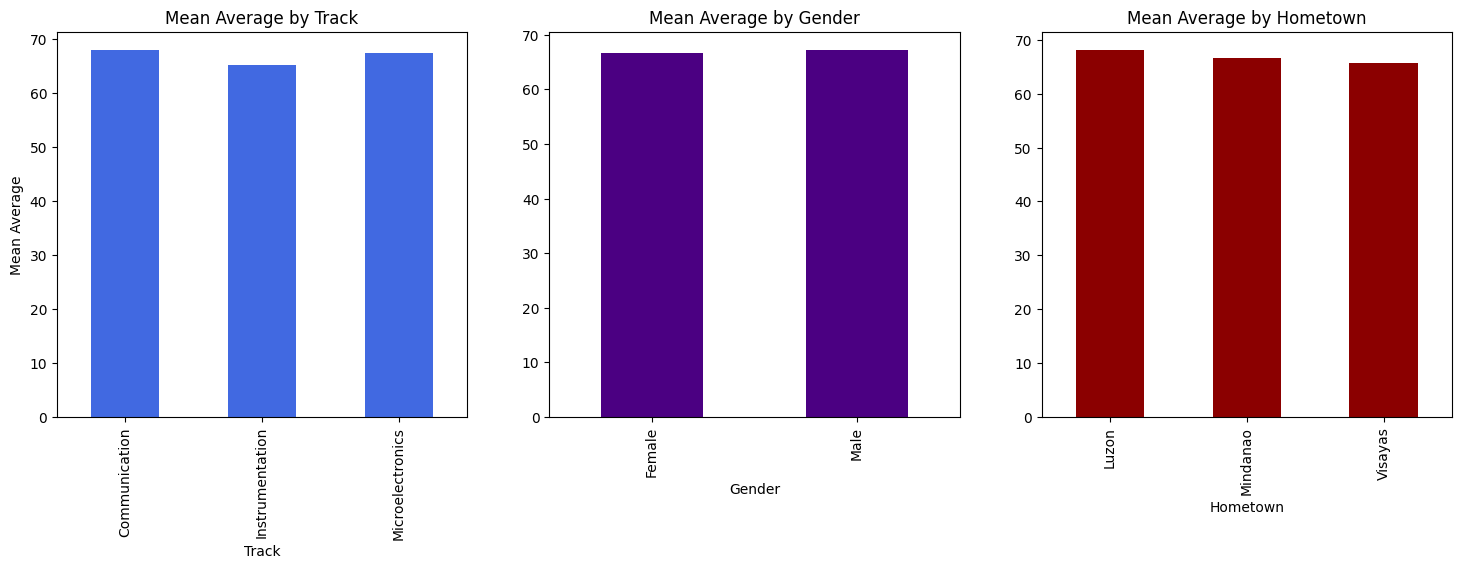

The Communication track has the highest sample mean of 67.975 among tracks.
The Male gender has the highest sample mean of 67.183 among genders.
Students from Luzon have the highest sample mean of 68.083 among hometowns.


In [87]:
# a. Compute 'Average' on the main DataFrame to ensure it exists
df['Average'] = df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

# b. Compute and display summary tables
for feature in ['Track', 'Gender', 'Hometown']:
    print(f"\nMean Average by {feature}:")
    display(df.groupby(feature)['Average'].mean().to_frame())

# Compute variables for plotting and statements
track_avg = df.groupby('Track')['Average'].mean()
gender_avg = df.groupby('Gender')['Average'].mean()
hometown_avg = df.groupby('Hometown')['Average'].mean()

# c. Create one figure containing three bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
track_avg.plot(kind='bar', ax=axes[0], color='royalblue', title='Mean Average by Track', ylabel='Mean Average')
gender_avg.plot(kind='bar', ax=axes[1], color='indigo', title='Mean Average by Gender')
hometown_avg.plot(kind='bar', ax=axes[2], color='darkred', title='Mean Average by Hometown')
plt.show()

# d. Write concise statements identifying categories with the highest sample mean
print(f"The {track_avg.idxmax()} track has the highest sample mean of {track_avg.max():.3f} among tracks.")
print(f"The {gender_avg.idxmax()} gender has the highest sample mean of {gender_avg.max():.3f} among genders.")
print(f"Students from {hometown_avg.idxmax()} have the highest sample mean of {hometown_avg.max():.3f} among hometowns.")